# [Title]

## Preparation

- https://github.com/Levine-l/CASA0006_project

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Exploratory Analysis](#Exploratory-Analysis)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

## Research questions

[[ go back to the top ]](#Table-of-contents)

To what extent is Year 6 obesity prevalence across London MSOAs associated with area deprivation, socio-demographic composition, and neighbourhood green cover?

## Data

[[ go back to the top ]](#Table-of-contents)

#### **Data Introduction**

This project uses five datasets to examine how Year 6 obesity in London is associated with deprivation, selected socio-demographic characteristics, and neighbourhood green cover at MSOA level.

The dependent variable is taken from the [Prevalence of Childhood Obesity, Borough, Ward and MSOA](https://data.london.gov.uk/dataset/prevalence-of-childhood-obesity-borough-ward-and-msoa-23g07/) dataset from the London Datastore, which reports childhood weight outcomes for Reception and Year 6 pupils at multiple spatial scales, including MSOA.

Neighbourhood deprivation is measured using the [English Indices of Deprivation 2019](https://data.london.gov.uk/dataset/indices-of-deprivation-2l15g/
), which provide official deprivation measures for London. Socio-demographic characteristics are drawn from the [2021 Census Bulk Data Download](https://www.nomisweb.co.uk/sources/census_2021_bulk
), which includes census tables for MSOA such as ethnicity, housing tenure, education level, population density and household composition.

The environmental variable is based on the [Green Cover 2024](https://data.london.gov.uk/dataset/green-cover-2024-e56n0/) dataset, which provides estimates of green cover in London and related spatial layers. Finally, [London’s Statistical GIS Boundary Files](https://data.london.gov.uk/dataset/statistical-gis-boundary-files-for-london-20od9/) are used to support spatial referencing and mapping at MSOA level.

#### **Data Processing**

For Child obesity prevalence data, I use the worksheet from 2011-12 to 2013-14, and only retain records with MSOA level. The main variable was Year 6 obesity prevalence, but there are small number of MSOA level Year 6 obesity values ('year6_obese_pct') were missing, from the website it may  because the original NCMP data contained suppressed estimates for disclosure control, including low counts and other confidentiality-related suppressions. Since the dependent variable is unavailable rather than partially observed, these cases are retained during data assembly but would excluded from modelling through complete-case analysis.

Deprivation data are using the IMD 2019, IDACI and IDAOPI, and Population figures sheets from the London IMD workbook. Because these data were provided at LSOA 2011 level, they were aggregated to MSOA level using population weighted means. Overall IMD and domain scores were weighted by total population, while IDACI and IDAOPI were weighted by child and older population respectively, but ranks and deciles were not aggregated because they are ordinal measures of relative position and are not meaningfully averaged.

Neighbourhood green cover was processed from the 2024 green cover polygon tiles. The raw spatial data were provided as multiple tiled shapefiles but not aggregated statistical table. I use London MSOA boundaries and spatially intersected with green cover polygons, and calculate the total green cover area within each MSOA. Then converte cpver area into a percentage of total MSOA area to create the green cover exposure variable.

Socio-demographic covariates included population density, ethnic composition, housing tenure, unemployment and economic inactivity, qualifications, and household structure, which from ts003, ts006, ts021, ts054, ts066 and ts067. Original counts are converted into percentages to improve comparability across MSOAs. Ethnic composition is represented by `pct_non_white` as a broad summary measure in order to keep the model parsimonious and reduce multicollinearity.

Apart from aggregation, geography mismatch was identified between datasets, because obesity data aligned with MSOA 2011, while census and the first processed green cover data aligned with MSOA 2021. So I using London MSOA 2011 as the anchor geography, green cover was recalculated directly onto MSOA 2011 boundaries, while census variables were harmonised from MSOA 2021 back to MSOA 2011 using the official ONS best-fit lookup ([Best fit](https://www.data.gov.uk/dataset/9aa055b1-9b55-4d40-9be0-70bab8d55889/msoa-2011-to-msoa-2021-to-local-authority-district-2022-best-fit-lookup-for-ew-v21) for matching, [exact fit](https://www.data.gov.uk/dataset/da36cac8-51c4-4d68-a4a9-37ac47d2a4ba/msoa-2011-to-msoa-2021-to-local-authority-district-2022-exact-fit-lookup-for-ew-v2) for comparing different). The final harmonised analysis dataset therefore combined obesity, IMD, green cover, and census covariates on a common MSOA 2011 geography.

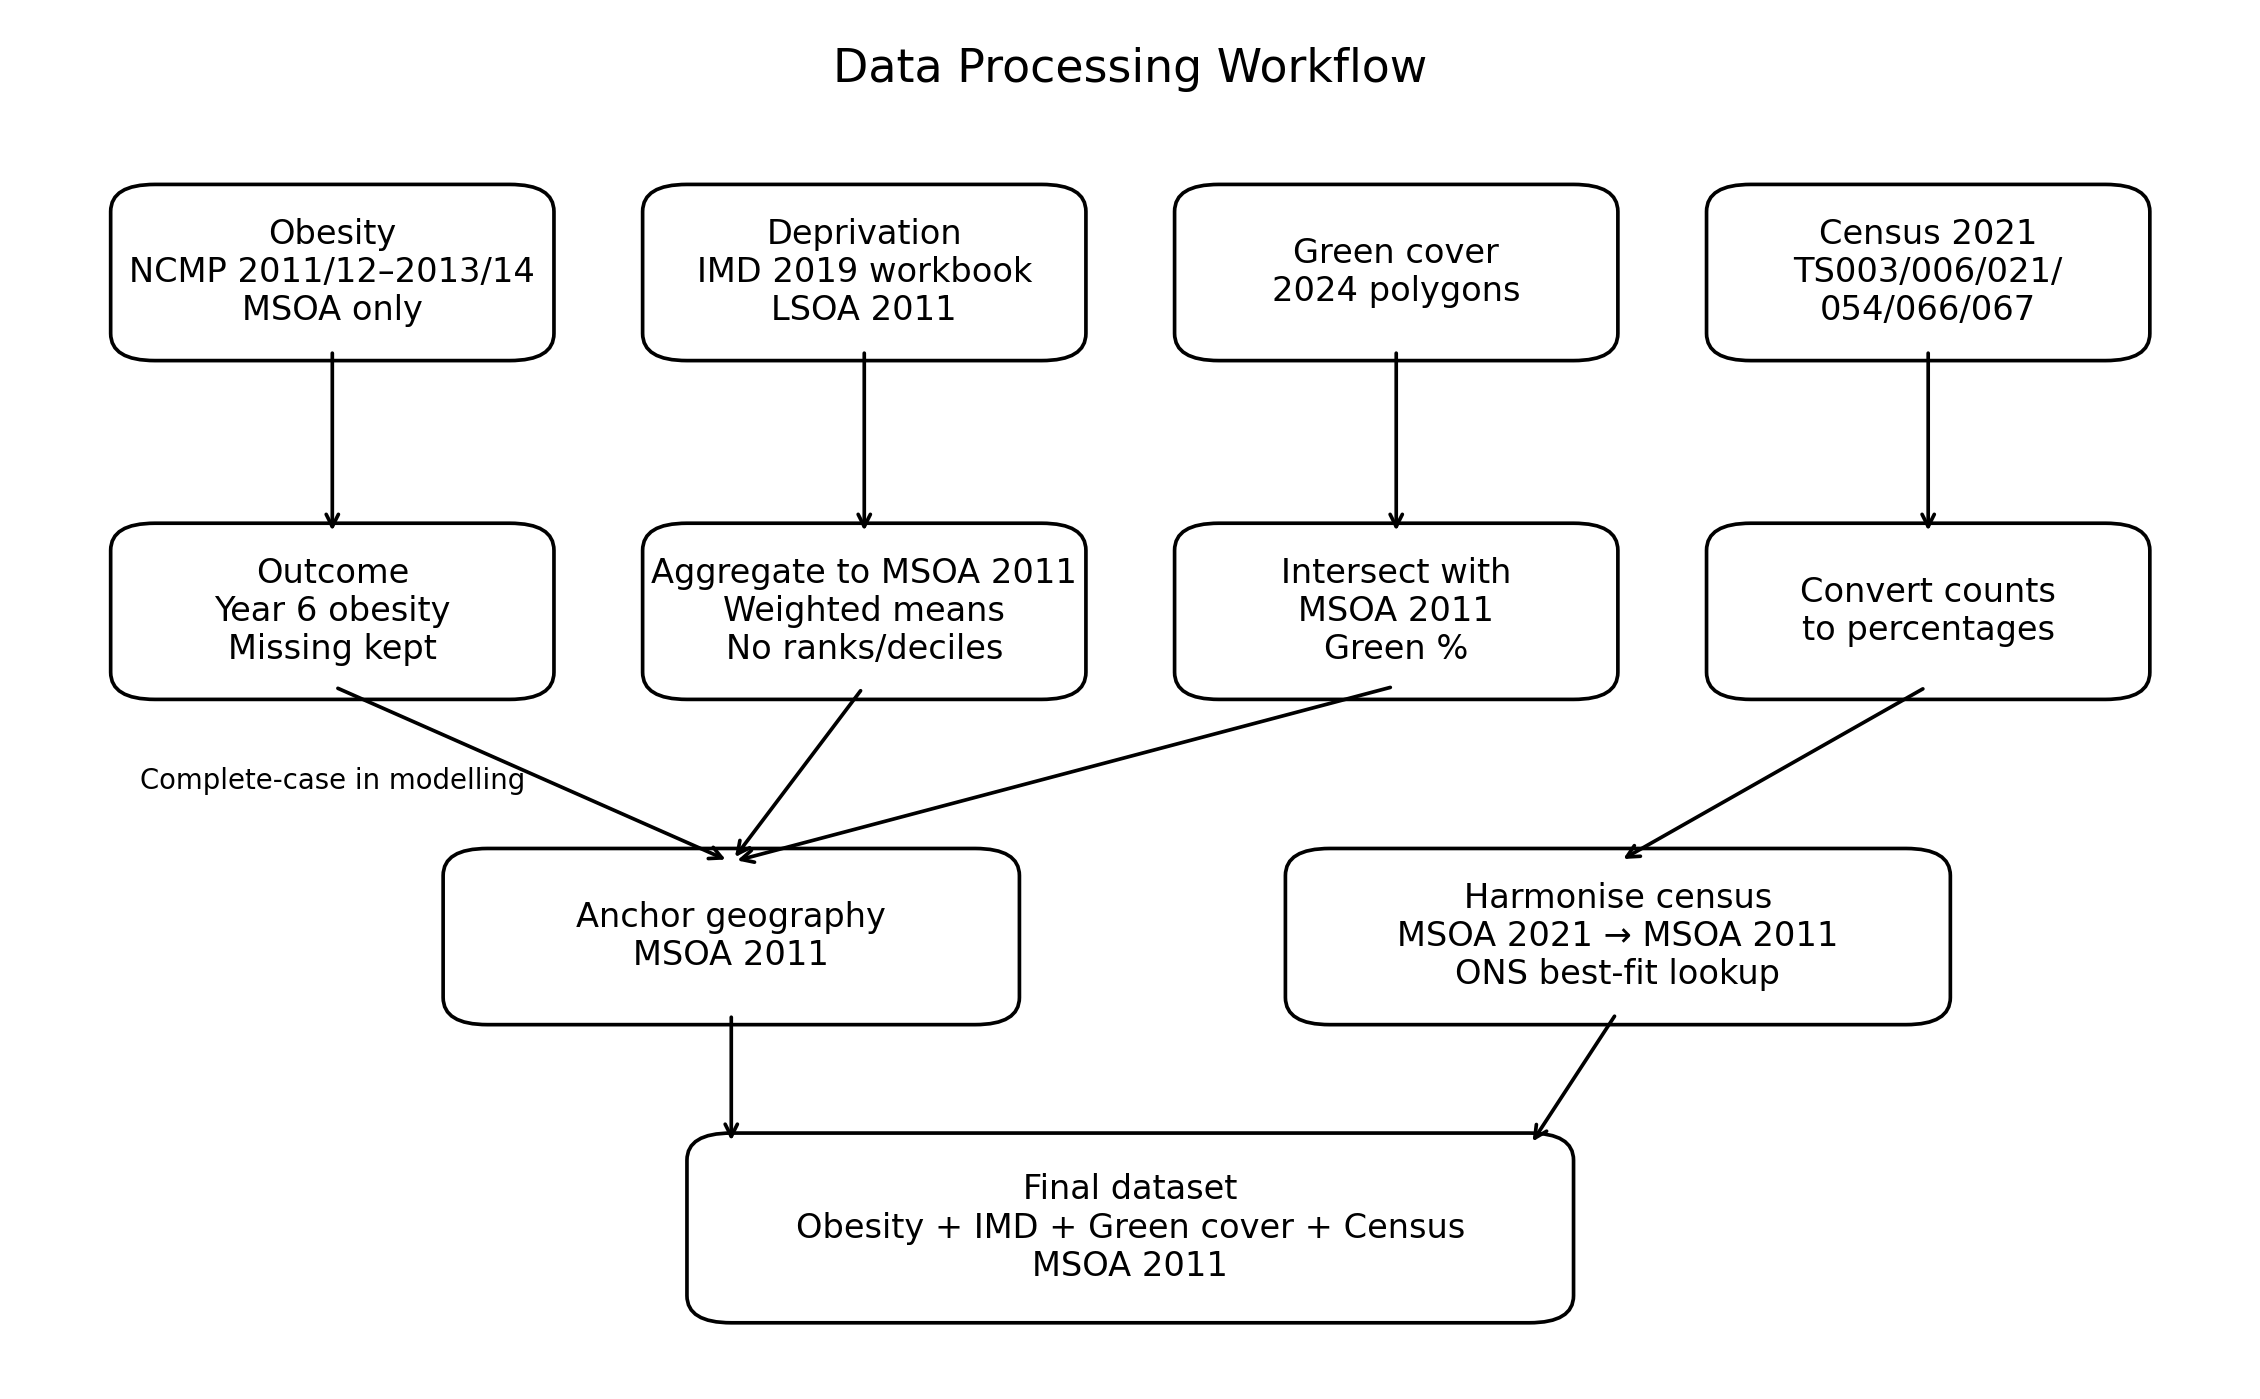

#### Variables used in the analysis

| Variable                                                                   | Type                     | Description                                                                                                      | Notes                                                                            |
| -------------------------------------------------------------------------- | ------------------------ | ---------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------- |
| Year 6 obesity prevalence (`year6_obese_pct`)                              | Numeric                  | Percentage of Year 6 children classified as obese at MSOA level. Used as the dependent variable in the analysis. | Main outcome variable.                                                           |
| Green cover percentage (`green_cover_pct`)                                 | Numeric                  | Percentage of land area classified as green cover within each MSOA. Used as the main exposure variable.          | Main exposure of interest.                                                       |
| Index of Multiple Deprivation score (`imd_score_weighted`)                 | Numeric                  | Population-weighted IMD 2019 score at MSOA level, representing overall area deprivation.                         | Main deprivation measure used in the core models.                                |
| Income Deprivation Affecting Children Index score (`idaci_score_weighted`) | Numeric                  | Child-population-weighted IDACI score at MSOA level, reflecting deprivation affecting children.                  | Used in sensitivity analysis rather than the main model due to overlap with IMD. |
| Population density (`population_density_per_sqkm`)                         | Numeric                  | Number of residents per square kilometre in each MSOA.                                                           | Included as a socio-demographic control.                                         |
| Black population percentage (`pct_black`)                                       | Numeric                  | Percentage of residents identifying as Black in each MSOA.                                                       | Socio-demographic covariate.                                                     |
| Asian population percentage (`pct_asian`)                                       | Numeric                  | Percentage of residents identifying as Asian in each MSOA.                                                       | Socio-demographic covariate.                                                     |
| Social rented housing percentage (`pct_social_rented`)                          | Numeric                  | Percentage of households living in socially rented accommodation in each MSOA.                                   | Socio-demographic covariate; may also reflect housing disadvantage.              |
| No qualifications percentage (`pct_no_qualifications`)                          | Numeric                  | Percentage of residents with no formal qualifications in each MSOA.                                              | Socio-demographic covariate.                                                     |
| Unemployment percentage (`pct_unemployed_16plus`)                               | Numeric                  | Percentage of residents aged 16+ who are unemployed in each MSOA.                                                | Socio-demographic covariate.                                                     |
| Lone-parent household percentage (`pct_lone_parent_households`)                 | Numeric                  | Percentage of households headed by a lone parent in each MSOA.                                                   | Socio-demographic covariate.                                                     |
| MSOA code (`MSOA_code`)                                                    | Categorical / Identifier | Unique code identifying each MSOA.                                                                               | Used for joining and reference only; not included as a predictor.                |
| MSOA name (`MSOA_name`)                                                    | Categorical / Identifier | Name of each MSOA.                                                                                               | Used for reporting and mapping only; not included as a predictor.                |
| Local authority district name (`LAD_name`)                                 | Categorical / Identifier | Name of the local authority district containing the MSOA.                                                        | Used for contextual reference only; not included as a predictor.                 |
| Exact fit match count (`exactfit_match_count`)                             | Numeric / Diagnostic     | Diagnostic field indicating the number of exact matches during spatial harmonisation or lookup.                  | Used for data quality checking only; not included in regression analysis.        |


## Methodology

[[ go back to the top ]](#Table-of-contents)

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

![image.png](attachment:image.png)

#### **Analytical strategy**

This study adopts a cross-sectional, MSOA-level analytical design to examine how Year 6 obesity prevalence in London is associated with neighbourhood green cover, area deprivation, and selected socio-demographic characteristics. The unit of analysis is the Middle Layer Super Output Area (MSOA). The dependent variable is Year 6 obesity prevalence (year6_obese_pct). The main explanatory variable is neighbourhood green cover percentage (green_cover_pct). Area deprivation is primarily represented by the population-weighted Index of Multiple Deprivation score (imd_score_weighted), while a child-focused deprivation measure, the Income Deprivation Affecting Children Index (idaci_score_weighted), is used in a sensitivity analysis rather than in the main model because of conceptual and statistical overlap with IMD.


The analysis is structured in three stages. First, descriptive and spatial exploratory analysis is used to examine the distribution of the outcome and key explanatory variables across London. Second, multivariable regression models are used to estimate the association between Year 6 obesity prevalence and the selected covariates. Third, sensitivity and diagnostic checks are used to assess whether the main findings are robust to alternative deprivation specifications and potential multicollinearity among predictors.

#### **Exploratory analysis**

The analysis begins with descriptive statistics for the outcome and explanatory variables, including measures of central tendency, dispersion, and missingness. Histograms and summary tables are used to inspect variable distributions. Spatial visualisation is then used to map Year 6 obesity prevalence, green cover, and deprivation across London MSOAs in order to identify broad spatial patterning and possible clustering.

Bivariate relationships are explored using scatterplots and a correlation matrix. This step is used to assess the direction and strength of pairwise relationships, especially between obesity prevalence and green cover, and between obesity prevalence and deprivation-related indicators. The exploratory analysis is not treated as causal evidence, but as a way to motivate the subsequent regression models and identify potential issues such as skewed distributions or high correlation among predictors.

#### **Regression modelling**
The main inferential approach is multivariable linear regression. This is appropriate because the research question is concerned with the extent to which Year 6 obesity prevalence is associated with environmental and socio-demographic characteristics, rather than with classification or purely predictive optimisation. Linear regression also provides coefficients that are relatively straightforward to interpret in substantive terms.

The modelling strategy is hierarchical. A baseline model includes the main deprivation variable only. A second model adds socio-demographic covariates, including population density, ethnic composition, housing tenure, educational disadvantage, unemployment, and lone-parent household prevalence. A third model adds green cover percentage in order to assess whether neighbourhood green cover remains associated with obesity prevalence after controlling for deprivation and socio-demographic composition.

This staged approach allows the analysis to distinguish between gross associations and associations that persist after adjustment for confounding area characteristics. The main focus is therefore on coefficient direction, relative magnitude, statistical significance, and changes in model fit across specifications.

#### **Variable handling and diagnostics**

Only substantively meaningful explanatory variables are included in the regression models. Identifier fields such as MSOA_code, MSOA_name, and LAD_name are used for joining, mapping, and reporting only, and are not treated as predictors. Likewise, harmonisation or matching diagnostics such as exactfit_match_count are used for data quality checking rather than as explanatory variables.

Because several area-level variables may capture related dimensions of deprivation and disadvantage, multicollinearity is assessed before fitting the final regression models. This is initially examined through the correlation matrix and then checked more formally using variance inflation factors. Where variables are found to be highly overlapping, model specifications are simplified to improve interpretability and reduce instability in coefficient estimates.

Cases with missing values on the dependent variable or selected modelling variables are excluded through complete-case analysis. This approach is appropriate here because the proportion of missing values is relatively small and the objective is to estimate consistent associations across a harmonised analytical dataset.

#### **Sensitivity analysis**

A sensitivity analysis is used to test whether the main findings depend on how deprivation is measured. In the core models, area deprivation is represented by imd_score_weighted. In an alternative specification, this is replaced by idaci_score_weighted, which captures child-related income deprivation more directly. This comparison is intended to assess whether the observed association between green cover and obesity prevalence is robust when a more child-specific deprivation indicator is used.

An optional comparison model using a non-linear machine learning approach, such as random forest regression, may also be estimated as a secondary robustness check. This model is not treated as the main inferential framework, but as a way to examine whether variable importance rankings are broadly consistent with the linear regression results.



#### **Limitations of the approach**

The methodology is designed to identify area-level associations rather than causal effects. The study uses cross-sectional data drawn from multiple sources that are not perfectly contemporaneous, so the results should be interpreted as approximate neighbourhood-level relationships rather than strict point-in-time effects. In addition, the analysis is conducted at MSOA level, which means that findings apply to spatial aggregates and should not be interpreted as evidence about individual children or households.

Furthermore, the use of `pct_non_white` as a broad measure of ethnic composition is a little rough and does not capture the significant heterogeneity in obesity risks and socio-economic outcomes across different specific ethnic groups.

## Exploratory Analysis
[[ go back to the top ]](#Table-of-contents)

#### Loading data

In [1]:
from pathlib import Path
import geopandas as gpd
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

#plotting style and resolution
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

#base directory and file paths
base_dir = Path.cwd()
#path from the github
data_path = "https://raw.githubusercontent.com/Levine-l/CASA0006_project/main/london_obe_analysis.csv"
boundary_path = "https://raw.githubusercontent.com/Levine-l/CASA0006_project/main/msoa_2011/MSOA_2011_London_gen_MHW.shp"

# Create directory for saving exploratory data analysis figures
fig_dir = base_dir / "report_figures" / "eda"
fig_dir.mkdir(parents=True, exist_ok=True)

#variables to be used in the regression analysis
eda_vars = [
    "MSOA_code",
    "MSOA_name",
    "LAD_name",
    "year6_obese_pct",
    "imd_score_weighted",
    "green_cover_pct",
    "population_density_per_sqkm",
    "pct_non_white",
    "pct_social_rented",
    "pct_no_qualifications",
    "pct_unemployed_16plus",
    "pct_lone_parent_households",
]

#load the main analysis dataset from GitHub
analysis = pd.read_csv(data_path)
#make sure MSOA codes are strings and stripped of whitespace for accurate merging
analysis["MSOA_code"] = analysis["MSOA_code"].astype(str).str.strip()

#load the London MSOA 2011 boundary
boundary = gpd.read_file(boundary_path)[["MSOA11CD", "MSOA11NM", "LAD11NM", "geometry"]].copy()
#rename boundary columns to match the main dataset identifiers
boundary = boundary.rename(
    columns={
        "MSOA11CD": "MSOA_code",
        "MSOA11NM": "MSOA_name_boundary",
        "LAD11NM": "LAD_name_boundary",
    }
)
boundary["MSOA_code"] = boundary["MSOA_code"].astype(str).str.strip()

#validate that all required core variables are present in the loaded dataset
missing_vars = [col for col in eda_vars if col not in analysis.columns]
if missing_vars:
    raise KeyError(f"Missing expected columns in harmonised dataset: {missing_vars}")

#create a subset of data for eda
eda = analysis[eda_vars].copy()
#merge analysis data with spatial boundaries for mapping
eda_map = boundary.merge(eda, on="MSOA_code", how="left")

#print summary of loaded data
print(f"Analysis data: {analysis.shape[0]} rows x {analysis.shape[1]} columns")
print(f"Boundary data: {boundary.shape[0]} MSOAs")
print(f"Records with obesity data after spatial merge: {eda_map['year6_obese_pct'].notna().sum()}")

Analysis data: 983 rows x 61 columns
Boundary data: 983 MSOAs
Records with obesity data after spatial merge: 959


#### 1. Data Overview

In [2]:
#calculate and display missing values for each variable
missingness = pd.DataFrame({
    "variable": eda_vars,
    "missing_n": [eda[col].isna().sum() for col in eda_vars],
})
missingness["missing_pct"] = (missingness["missing_n"] / len(eda) * 100).round(2)
missingness = missingness.sort_values(["missing_pct", "variable"], ascending=[False, True]).reset_index(drop=True)

#show the missingness summary table
display(missingness)

#define the subset of numeric variables
summary_vars = [
    "year6_obese_pct",
    "imd_score_weighted",
    "green_cover_pct",
    "population_density_per_sqkm",
    "pct_non_white",
    "pct_social_rented",
    "pct_no_qualifications",
    "pct_unemployed_16plus",
    "pct_lone_parent_households",
]

#descriptive statistics for the chosen variables
summary_table = eda[summary_vars].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
summary_table = summary_table.round(2)

#display summary statistics table
display(summary_table)

,variable,missing_n,missing_pct
0,year6_obese_pct,24,2.44
1,LAD_name,0,0.00
2,MSOA_code,0,0.00
3,MSOA_name,0,0.00
4,green_cover_pct,0,0.00
5,imd_score_weighted,0,0.00
6,pct_lone_parent_households,0,0.00
7,pct_no_qualifications,0,0.00
8,pct_non_white,0,0.00
9,pct_social_rented,0,0.00


,count,mean,std,min,25%,50%,75%,max
year6_obese_pct,959.0,21.83,5.46,5.63,18.46,22.58,25.80,39.68
imd_score_weighted,983.0,21.50,9.34,4.04,13.77,21.02,28.58,49.74
green_cover_pct,983.0,39.36,16.16,3.18,27.13,37.81,48.79,92.67
population_density_per_sqkm,983.0,8846.13,4966.55,302.30,5019.20,7896.30,12042.05,23873.40
pct_non_white,983.0,45.01,17.51,6.62,30.86,43.61,57.49,96.02
pct_social_rented,983.0,22.66,15.00,1.32,10.43,19.54,32.39,72.59
pct_no_qualifications,983.0,16.18,5.60,4.67,11.69,15.86,20.16,33.79
pct_unemployed_16plus,983.0,4.77,1.30,1.70,3.71,4.77,5.70,9.16
pct_lone_parent_households,983.0,13.33,4.82,3.56,9.74,12.61,16.33,33.09


#### 2. Histogram of Y6 Obesity Prevalence

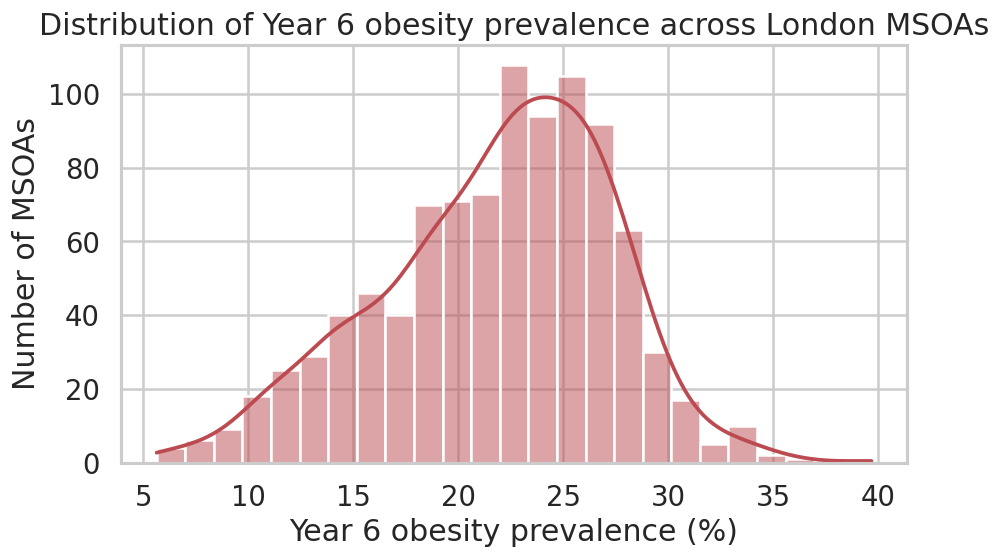

In [3]:
#figure size for the plot
fig, ax = plt.subplots(figsize=(8, 5))

#histogram where x is the Year 6 obesity percentage and y is the number of msoa
#with a kernel density estimate curve plot
sns.histplot(data=eda, x="year6_obese_pct", bins=25, kde=True, color="#bc4b51", edgecolor="white", ax=ax)

ax.set_title("Distribution of Year 6 obesity prevalence across London MSOAs")
ax.set_xlabel("Year 6 obesity prevalence (%)")
ax.set_ylabel("Number of MSOAs")

#adjust layout
fig.tight_layout()

# Save the generated histogram to the specified directory as a PNG file
fig.savefig(fig_dir / "hist_year6_obese_pct.png", bbox_inches="tight")

# Display the plot in the notebook output
plt.show()

The distribution of obesity prevalence of Year 6 in London's MSOAs are concentrated between 15% and 30%, with a peak of about 24%. The obesity prevalence of a small number of MSOAs is relatively low or high, but there is no obvious skew in the overall distribution. This shows that the dependent variable has significant spatial variability.

#### 3. Choropleth Map

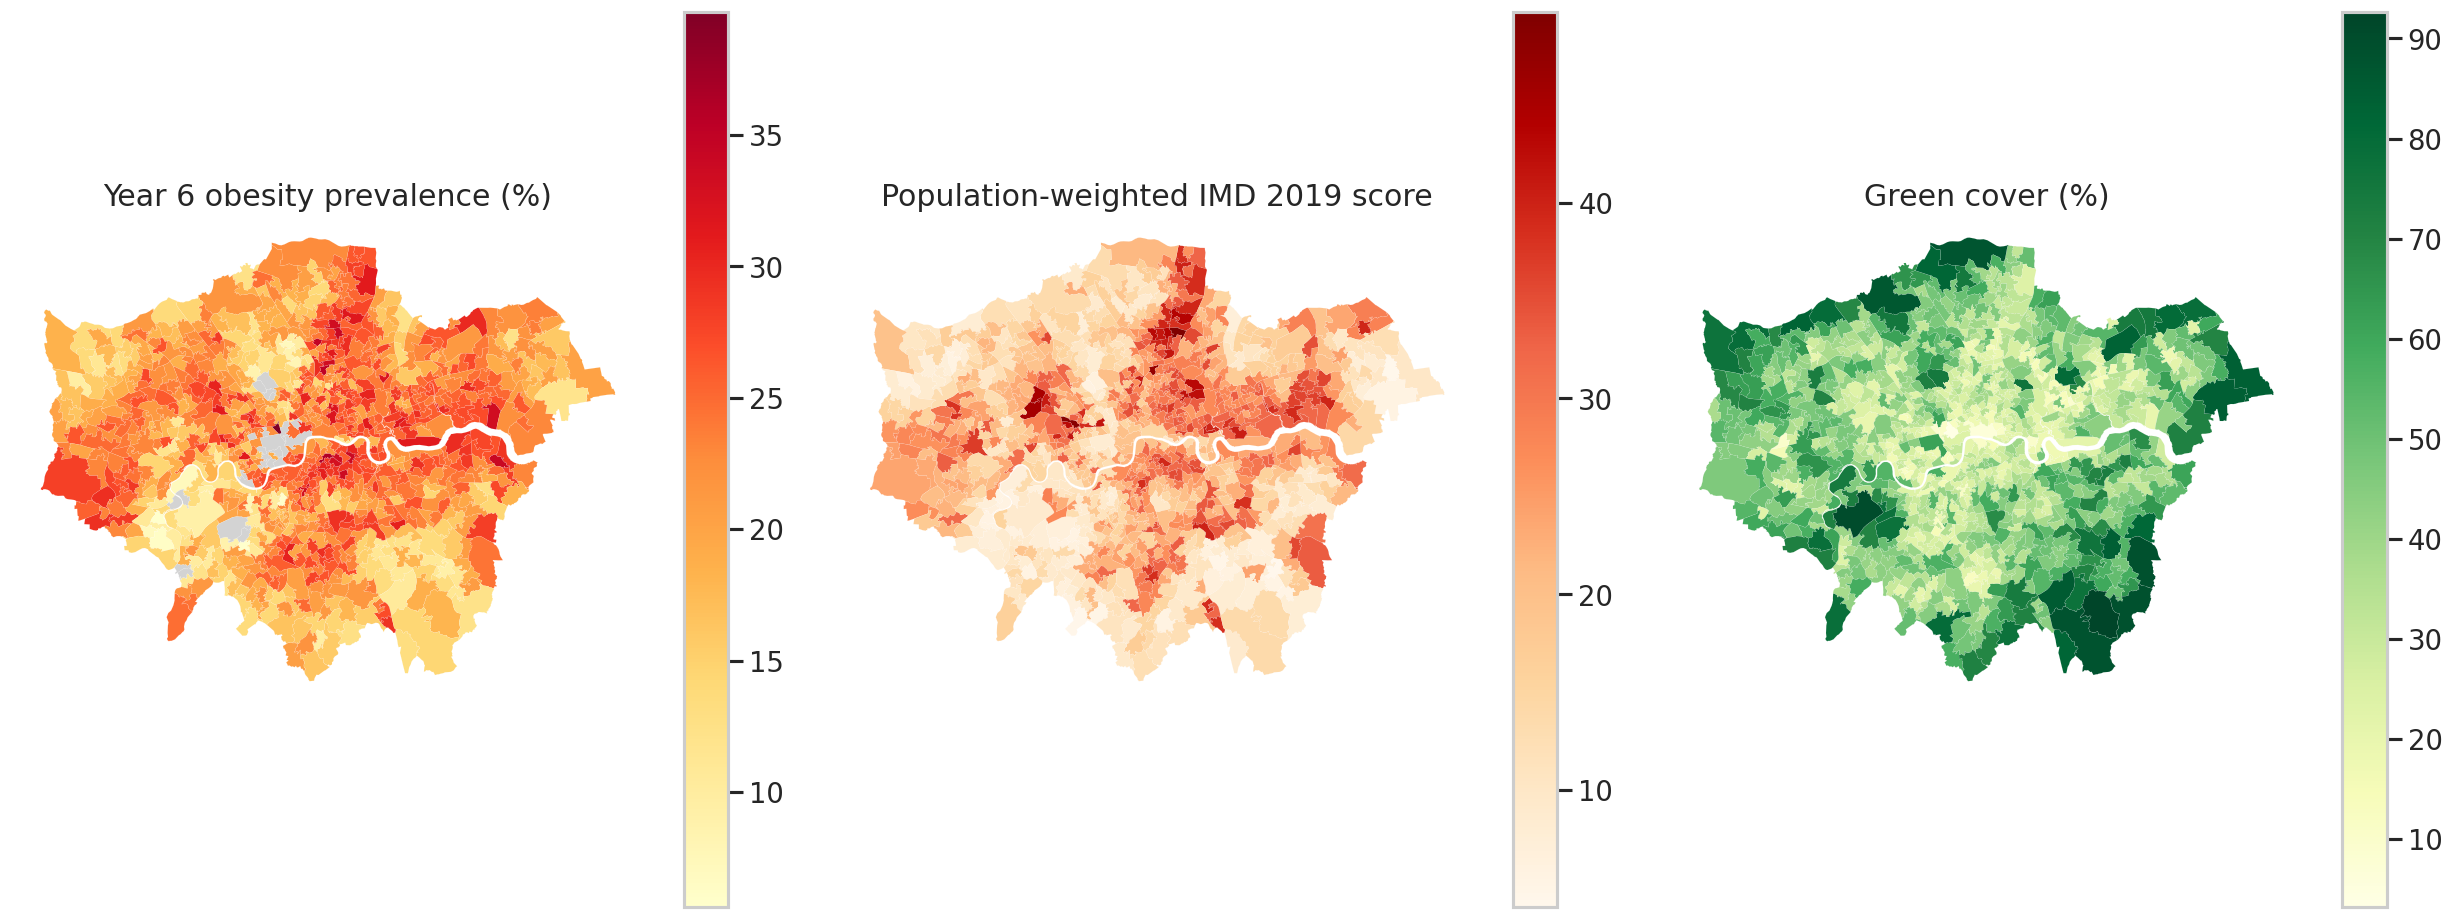

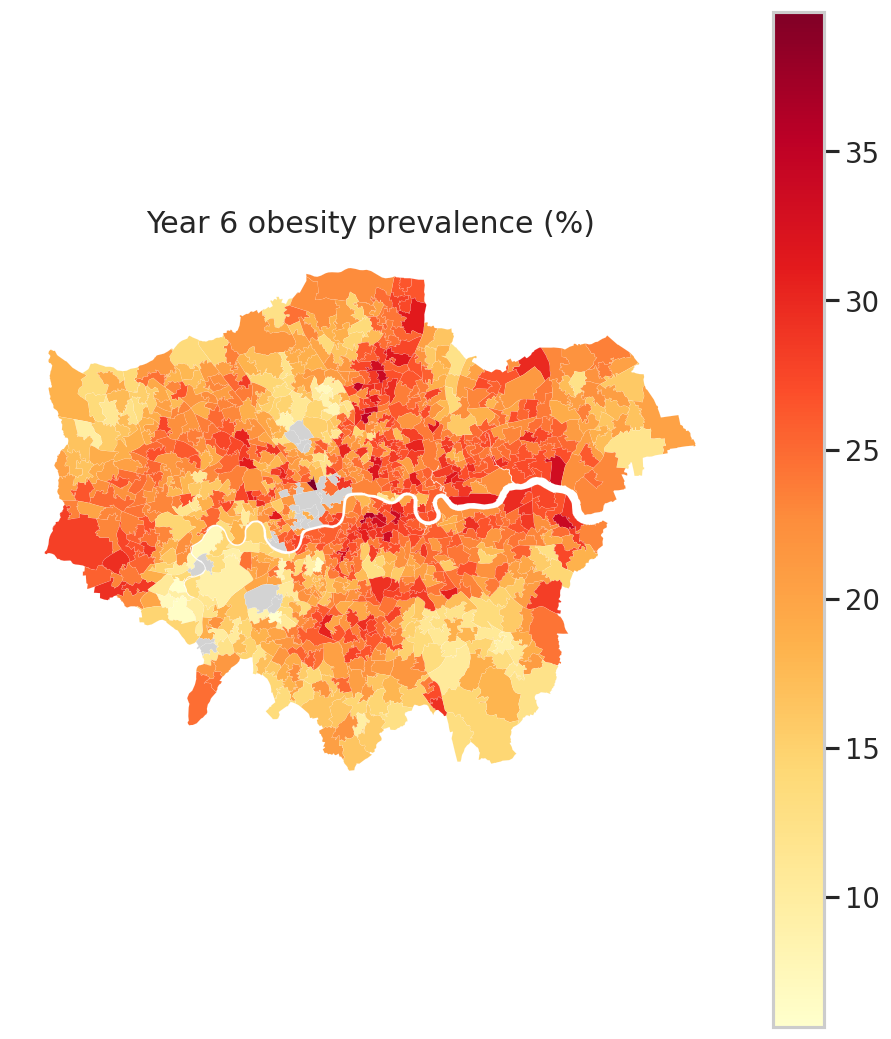

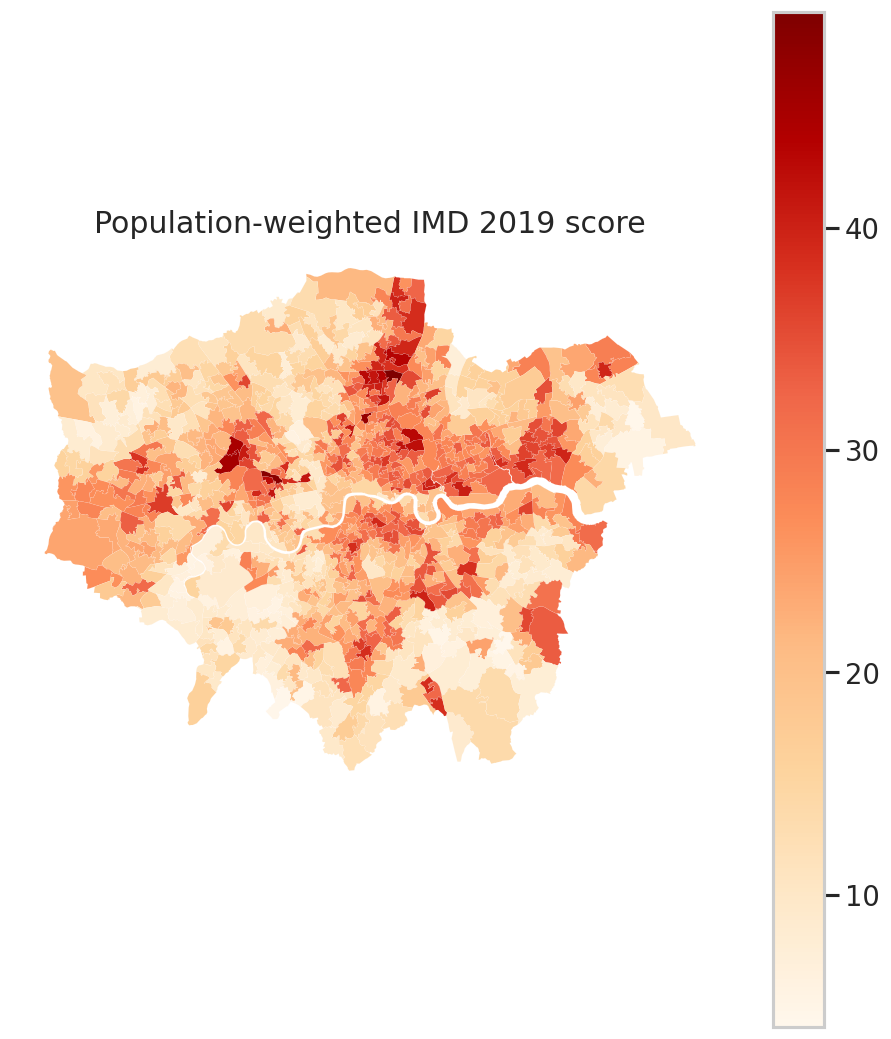

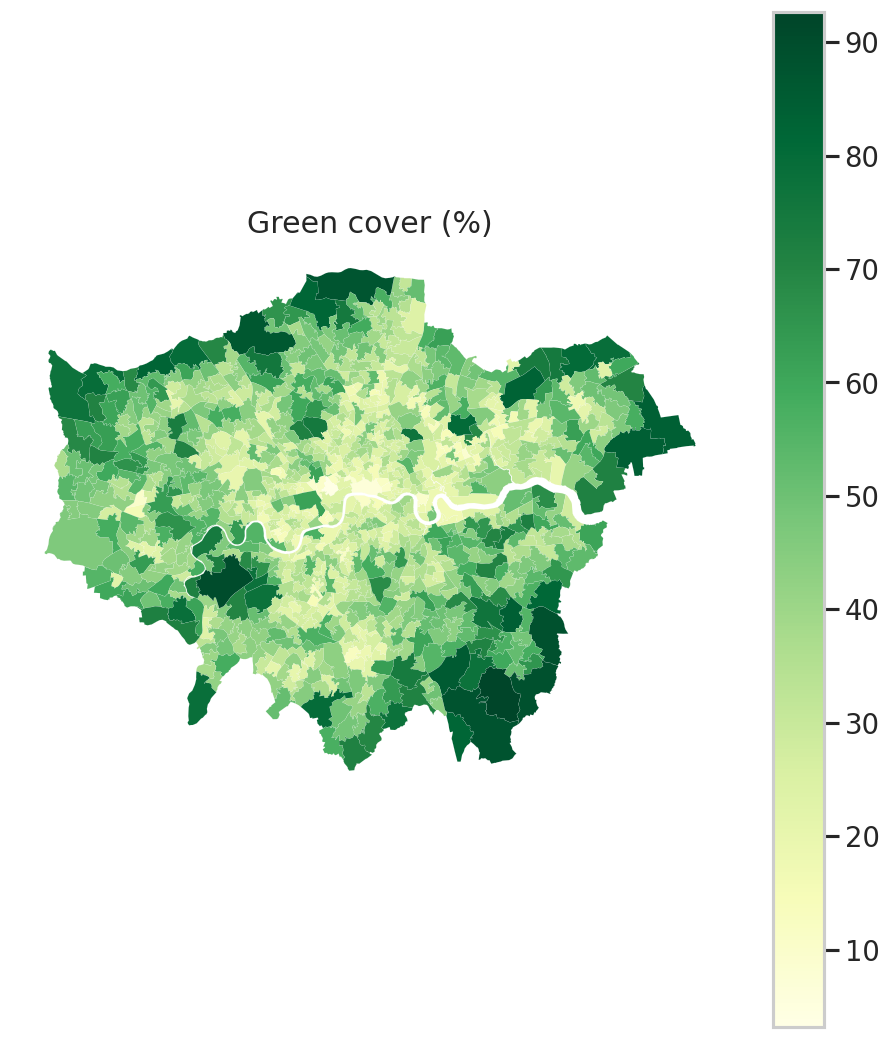

In [4]:
#define the map
map_specs = [
    ("year6_obese_pct", "Year 6 obesity prevalence (%)", "YlOrRd", "map_year6_obese_pct.png"),
    ("imd_score_weighted", "Population-weighted IMD 2019 score", "OrRd", "map_imd_score_weighted.png"),
    ("green_cover_pct", "Green cover (%)", "YlGn", "map_green_cover_pct.png"),
]

#combined 3 plot figure for overview
fig, axes = plt.subplots(1, 3, figsize=(21, 8))

#plot the choropleth map
for ax, (column, title, cmap, _) in zip(axes, map_specs):
    eda_map.plot(
        column=column,
        cmap=cmap,
        linewidth=0.05,
        edgecolor="white",
        legend=True,
        missing_kwds={"color": "lightgrey", "label": "Missing"}, #dealing MSOAs with no data
        ax=ax,
    )
    ax.set_title(title)
    ax.set_axis_off() #hide x y coordinates

fig.tight_layout()

# Save the combined overview plot
fig.savefig(fig_dir / "maps_core_variables.png", bbox_inches="tight")

plt.show()

#create another larger maps
for column, title, cmap, filename in map_specs:
    fig, ax = plt.subplots(figsize=(8, 9))
    eda_map.plot(
        column=column,
        cmap=cmap,
        linewidth=0.05,
        edgecolor="white",
        legend=True,
        missing_kwds={"color": "lightgrey", "label": "Missing"},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_axis_off()
    fig.tight_layout()

    # Save each specific map using the filename defined in map_specs
    fig.savefig(fig_dir / filename, bbox_inches="tight")
    plt.show()

The choropleth maps shows spatial variation in Year 6 obesity prevalence across London MSOAs. Higher obesity prevalence appears more common in centre and some of the west and northeast parts of the city, while greener areas are more commonly located towards the outer parts of London.

The deprivation map shows a broadly similar spatial pattern to the obesity map, whereas the green cover map shows a more contrasting pattern. This can suggests that both deprivation and neighbourhood environment may be relevant to explaining area variation in childhood obesity.

To assess these relationships more directly, scatterplots are nessacery.

#### 4. Key Scatterplots

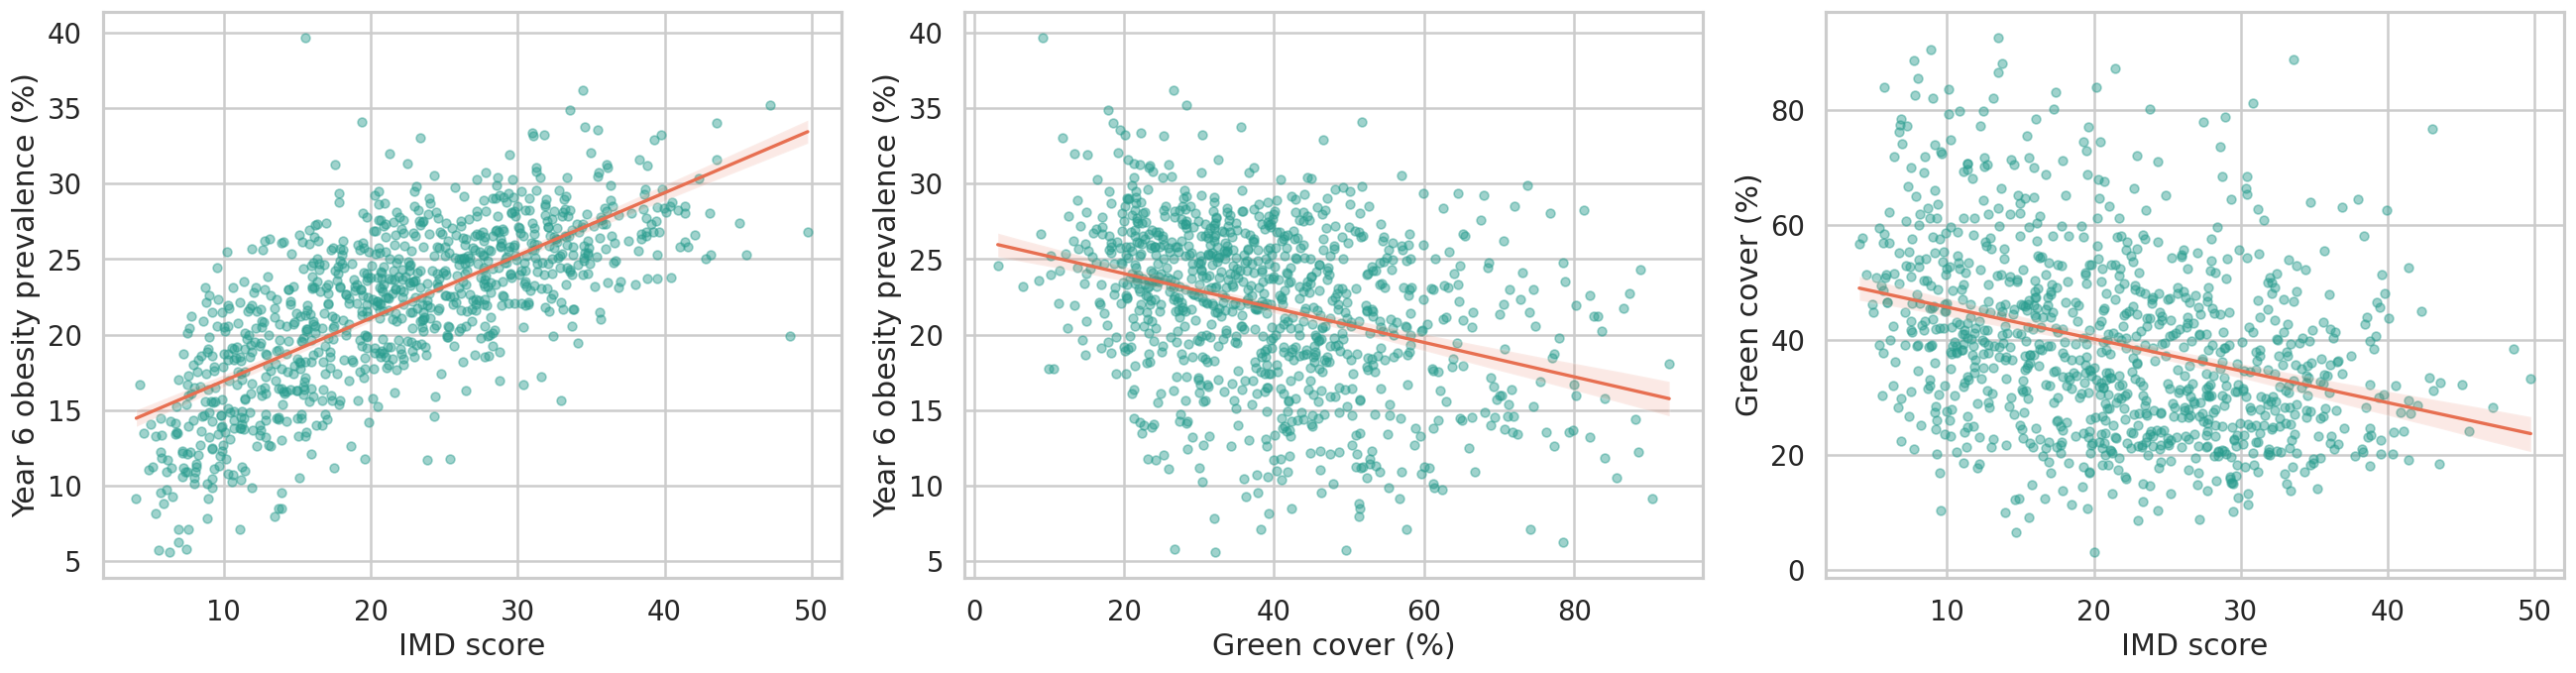

In [5]:
#define the scatterplot pairs
scatter_specs = [
    ("imd_score_weighted", "year6_obese_pct", "IMD score", "Year 6 obesity prevalence (%)"),
    ("green_cover_pct", "year6_obese_pct", "Green cover (%)", "Year 6 obesity prevalence (%)"),
    ("imd_score_weighted", "green_cover_pct", "IMD score", "Green cover (%)"),
]

#a multi-plot figure for key bivariate relationships
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, (x_var, y_var, x_label, y_label) in zip(axes, scatter_specs):
    plot_df = eda[[x_var, y_var]].dropna().copy()#drop missing values

    #seaborn regplot to show scatter points and fitted linear regression line
    sns.regplot(
        data=plot_df,
        x=x_var,
        y=y_var,
        scatter_kws={"alpha": 0.45, "s": 28, "color": "#2a9d8f"}, #point's transparency and size
        line_kws={"color": "#e76f51", "lw": 2}, #regression line appearance
        ax=ax,
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

# Adjust layout and save the visualization
fig.tight_layout()
fig.savefig(fig_dir / "scatterplots_key_relationships.png", bbox_inches="tight")
plt.show()

In the scatter plot, there is a significant positive correlation between Year 6 obesity prevalence and IMD scores. Conversely, green coverage is negatively correlated with obesity prevalence.

There is also negative correlation between IMD scores and green coverage, which is areas with higher levels of green coverage have lower levels of poverty.

#### 5. Correlation Heatmap

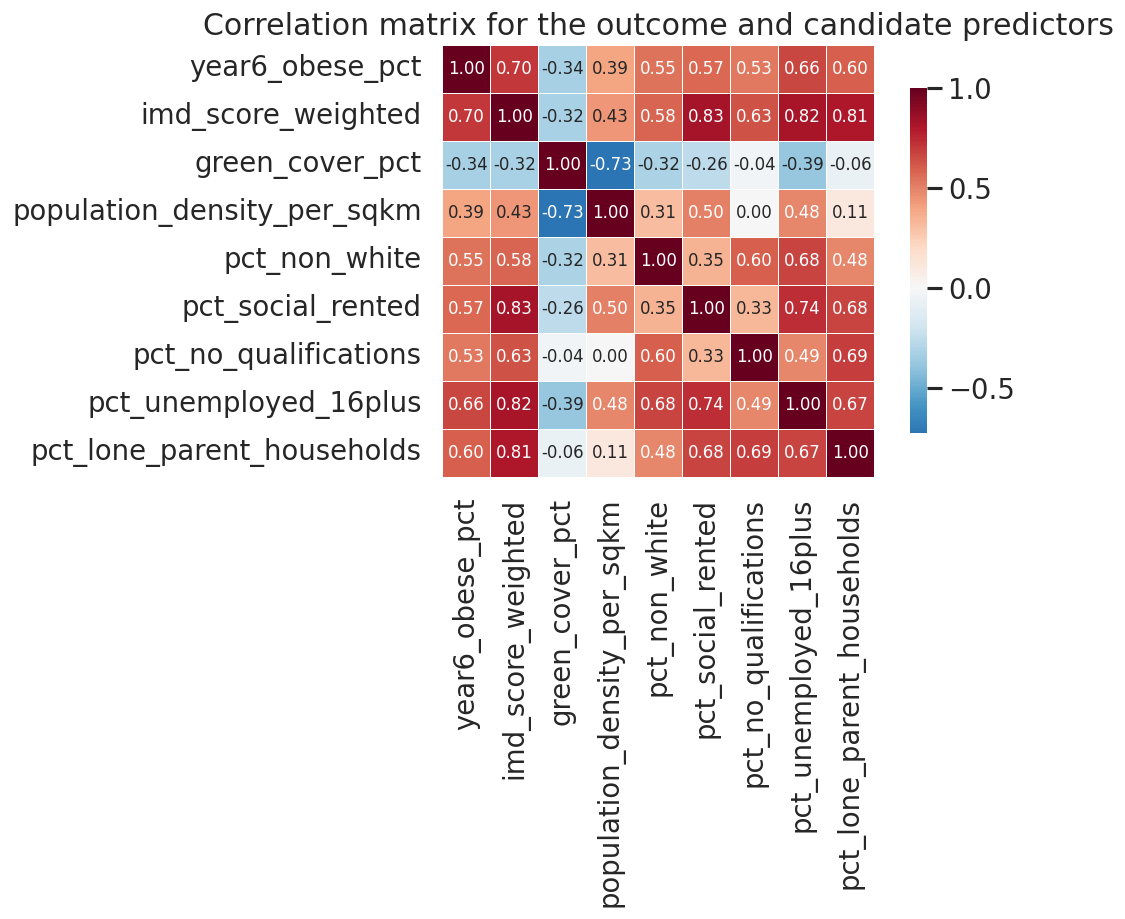

,correlation_with_year6_obese_pct
year6_obese_pct,1.000000
imd_score_weighted,0.704459
pct_unemployed_16plus,0.664553
pct_lone_parent_households,0.598388
pct_social_rented,0.574534
pct_non_white,0.546697
pct_no_qualifications,0.525397
population_density_per_sqkm,0.394047
green_cover_pct,-0.336009


In [6]:
#variables for the correlation analysis
heatmap_vars = [
    "year6_obese_pct",
    "imd_score_weighted",
    "green_cover_pct",
    "population_density_per_sqkm",
    "pct_non_white",
    "pct_social_rented",
    "pct_no_qualifications",
    "pct_unemployed_16plus",
    "pct_lone_parent_households",
]

#compute Pearson correlation matrix
corr_df = eda[heatmap_vars].copy()
corr_matrix = corr_df.corr(numeric_only=True)

#the heatmap visualization
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap="RdBu_r", #red-blue color map
    center=0,
    annot=True, #print the correlation coefficients in each cell
    annot_kws={"size": 10},#aadjust the size of numbers
    fmt=".2f",#format coefficients to 2 decimal places
    square=True,#ensure cells are square shape
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)

ax.set_title("Correlation matrix for the outcome and candidate predictors")
fig.tight_layout()

# Save and display the heatmap
fig.savefig(fig_dir / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

#a ranked list of correlations with obesity
corr_with_outcome = corr_matrix["year6_obese_pct"].sort_values(ascending=False)
display(corr_with_outcome.to_frame(name="correlation_with_year6_obese_pct"))

Accroding to the correlation matrix, Year 6 obesity prevalence is strongly positively correlated with the IMD score and moderately negatively correlated with green cover. Several socio-demographic variables associated with disadvantage like social renting, unemployment, and lone-parent households are also positively correlated with both obesity prevalence and deprivation.

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

The main regression analysis uses complete-case observations with non-missing values on the outcome and all predictors included in models 1–3.

In [7]:
# Define directories for output tables and figures
TABLE_DIR = base_dir / "report_tables" / "results"
FIG_DIR = base_dir / "report_figures" / "results"

# Create the directories if they don't already exist
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

#group variables
identifier_vars = ["MSOA_code", "MSOA_name", "LAD_name"] #labels
outcome = "year6_obese_pct"#dependent variable
deprivation_var = "imd_score_weighted"#primary predictor
green_var = "green_cover_pct" #exposure variable

#additional socio-demographic variables
sociodemographic_vars = [
    "population_density_per_sqkm",
    "pct_non_white",
    "pct_social_rented",
    "pct_no_qualifications",
    "pct_unemployed_16plus",
    "pct_lone_parent_households",
]

#combine all core variables into a single list for data subset
model_core_vars = identifier_vars + [outcome, deprivation_var, green_var] + sociodemographic_vars

#alternative deprivation measure for robustness check
sensitivity_vars = ["idaci_score_weighted"]

#define the components for hierarchical modeling
model_1_vars = [deprivation_var] #baseline which is deprivation only
model_2_additions = sociodemographic_vars.copy() #add socio-demographics
model_3_additions = [green_var] #add green cover

#### 1. Build the Modelling Dataset

In [8]:
#all unique variables required for the primary and sensitivity models
required_vars = model_core_vars + sensitivity_vars
required_vars = list(dict.fromkeys(required_vars)) #remove duplicates and keeping order

#check if any required variables are missing from the input dataframe
missing_vars = [col for col in required_vars if col not in analysis.columns]
if missing_vars:
    raise KeyError(f"Missing expected columns in harmonised dataset: {missing_vars}")

#a subset dataframe containing only the necessary modeling columns
model_data = analysis[required_vars].copy()

#calculate missingness each variable to evaluate data quality for the regression
missingness = pd.DataFrame({
    "variable": required_vars,
    "missing_n": [model_data[col].isna().sum() for col in required_vars],
})
missingness["missing_pct"] = (missingness["missing_n" ] / len(model_data) * 100).round(2)
display(missingness.sort_values(["missing_pct", "variable"], ascending=[False, True]).reset_index(drop=True))

#identify variables needed for regression models (models 1-3)
core_model_vars = [outcome] + model_1_vars + model_2_additions + model_3_additions

#drop any rows with missing values in the outcome or core predictors (complete-case analysis)
complete_case = model_data.dropna(subset=core_model_vars).copy()
complete_case = complete_case.reset_index(drop=True)

#print summary
print(f"Rows in full harmonised dataset: {len(model_data)}")
print(f"Rows in complete-case regression dataset: {len(complete_case)}")
print(f"Rows dropped for main regression models: {len(model_data) - len(complete_case)}")

,variable,missing_n,missing_pct
0,year6_obese_pct,24,2.44
1,LAD_name,0,0.00
2,MSOA_code,0,0.00
3,MSOA_name,0,0.00
4,green_cover_pct,0,0.00
5,idaci_score_weighted,0,0.00
6,imd_score_weighted,0,0.00
7,pct_lone_parent_households,0,0.00
8,pct_no_qualifications,0,0.00
9,pct_non_white,0,0.00


Rows in full harmonised dataset: 983
Rows in complete-case regression dataset: 959
Rows dropped for main regression models: 24


#### 2. Fit Hierarchical Linear Regression Models

In [9]:
#model 1 exploring the association with deprivation only
formula_1 = f"{outcome} ~ {deprivation_var}"
#model 2 adding socio-demographic control variables
formula_2 = f"{outcome} ~ {deprivation_var} + {' + '.join(sociodemographic_vars)}"
#model 3 full model adding the green cover
formula_3 = f"{formula_2} + {green_var}"

#fit the models using ordinary least squares
model_1 = smf.ols(formula=formula_1, data=complete_case).fit(cov_type="HC3")#use cov_type="HC3" to compute heteroscedasticity-robust standard errors(ensure reliable p value)
model_2 = smf.ols(formula=formula_2, data=complete_case).fit(cov_type="HC3")
model_3 = smf.ols(formula=formula_3, data=complete_case).fit(cov_type="HC3")

#print the summaries
#print(model_1.summary())
#print(model_2.summary())
#print(model_3.summary())

#store the full summaries for checking, but keep the final notebook output concise\n",
model_summaries = {
    "Model 1": model_1.summary(),
    "Model 2": model_2.summary(),
    "Model 3": model_3.summary(),
}
print("Models fitted successfully. Full statsmodels summaries are retained in `model_summaries` for checking but are not displayed here.")

Models fitted successfully. Full statsmodels summaries are retained in `model_summaries` for checking but are not displayed here.


In [10]:
#define a function to extract and format key regression statistics
def tidy_model(model, model_name):
    conf = model.conf_int()
    out = pd.DataFrame({
        "term": model.params.index,
        "coef": model.params.values,
        "std_err": model.bse.values,
        "p_value": model.pvalues.values,
        "ci_low": conf[0].values,
        "ci_high": conf[1].values,
        "model": model_name,
    })
    return out

#combine the results from all three models into a single table for comparison
tidy_results = pd.concat([
    tidy_model(model_1, "Model 1"),
    tidy_model(model_2, "Model 2"),
    tidy_model(model_3, "Model 3"),
], ignore_index=True)

#display the combined results
display(tidy_results.round(4))
tidy_results.to_csv(TABLE_DIR / "regression_tidy_results.csv", index=False)

,term,coef,std_err,p_value,ci_low,ci_high,model
0,Intercept,12.7946,0.3503,0.0000,12.1081,13.4810,Model 1
1,imd_score_weighted,0.4150,0.0140,0.0000,0.3875,0.4426,Model 1
2,Intercept,7.9851,0.6787,0.0000,6.6548,9.3155,Model 2
3,imd_score_weighted,0.1484,0.0382,0.0001,0.0734,0.2233,Model 2
4,population_density_per_sqkm,0.0002,0.0000,0.0000,0.0001,0.0002,Model 2
5,pct_non_white,0.0322,0.0100,0.0014,0.0125,0.0519,Model 2
6,pct_social_rented,0.0032,0.0172,0.8508,-0.0305,0.0370,Model 2
7,pct_no_qualifications,0.1529,0.0367,0.0000,0.0810,0.2248,Model 2
8,pct_unemployed_16plus,0.6649,0.2215,0.0027,0.2309,1.0990,Model 2
9,pct_lone_parent_households,0.1372,0.0519,0.0082,0.0354,0.2390,Model 2


In [11]:
#build a summary table of model
model_fit = pd.DataFrame([
    {
        "model": "Model 1",
        "formula": formula_1,
        "n": int(model_1.nobs),
        "r_squared": model_1.rsquared,
        "adj_r_squared": model_1.rsquared_adj,
        "aic": model_1.aic,
        "bic": model_1.bic,
    },
    {
        "model": "Model 2",
        "formula": formula_2,
        "n": int(model_2.nobs),
        "r_squared": model_2.rsquared,
        "adj_r_squared": model_2.rsquared_adj,
        "aic": model_2.aic,
        "bic": model_2.bic,
    },
    {
        "model": "Model 3",
        "formula": formula_3,
        "n": int(model_3.nobs),
        "r_squared": model_3.rsquared,
        "adj_r_squared": model_3.rsquared_adj,
        "aic": model_3.aic,
        "bic": model_3.bic,
    },
]).round(4)

#display the fit summary
display(model_fit)
model_fit.to_csv(TABLE_DIR / "regression_model_fit.csv", index=False)

,model,formula,n,r_squared,adj_r_squared,aic,bic
0,Model 1,year6_obese_pct ~ imd_score_weighted,959,0.4963,0.4957,5323.4460,5333.1778
1,Model 2,year6_obese_pct ~ imd_score_weighted + populat...,959,0.5567,0.5535,5212.7946,5251.7218
2,Model 3,year6_obese_pct ~ imd_score_weighted + populat...,959,0.5581,0.5544,5211.8715,5255.6645


From the regression results, area deprivation alone can explains a substantial ratio of variation in Year 6 obesity prevalence across London MSOAs.

The R^2 of Model 1 which includes only the population-weighted IMD score achieves 0.496, indicate that IMD can be the most important factor.

Adding socio-demographic covariates in Model 2 improves model fit to R^2 = 0.557, so neighbourhood composition can provides additional explanation.

However, after adding green cover in Model 3, only improve slightly, which is less than 0.002 in R^2.

#### 3. Coefficient Comparison Plot

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


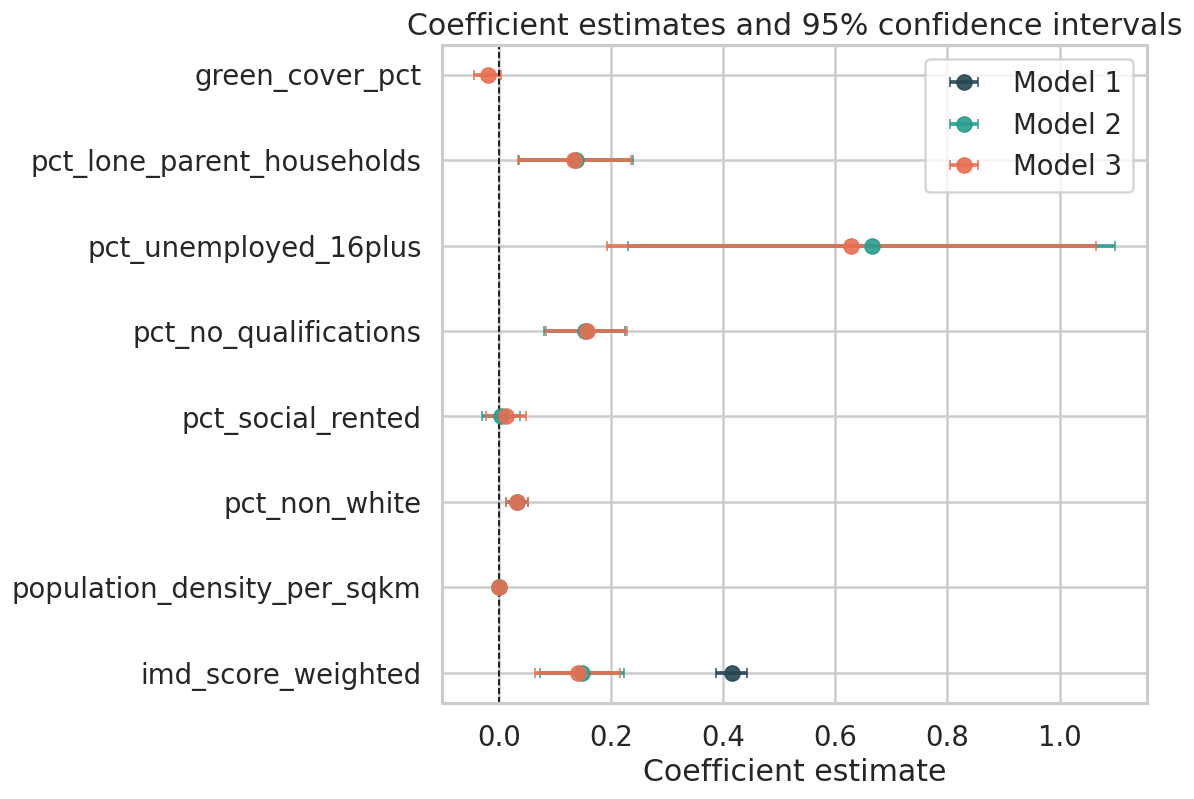

In [12]:
#excluding the intercept
plot_df = tidy_results.loc[tidy_results["term"] != "Intercept"].copy()
#sort terms from top to bottom
plot_df["term"] = pd.Categorical(plot_df["term"], categories=list(reversed(plot_df["term"].unique())), ordered=True)

fig, ax = plt.subplots(figsize=(10, 7))
palette = {"Model 1": "#264653", "Model 2": "#2a9d8f", "Model 3": "#e76f51"}

#plot point estimates and 95% confidence intervals for each hierarchical model
for model_name, sub in plot_df.groupby("model"):
    ax.errorbar(
        x=sub["coef"],
        y=sub["term"],
        xerr=[sub["coef"] - sub["ci_low"], sub["ci_high" ] - sub["coef"]],
        fmt="o",
        capsize=3,
        label=model_name,
        color=palette[model_name],
        alpha=0.9,
    )

#add a reference line at zero to identify statistically significant predictors
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Coefficient estimates and 95% confidence intervals")
ax.set_xlabel("Coefficient estimate")
ax.set_ylabel("")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "coefficients_comparison.png", bbox_inches="tight")
plt.show()

The coefficient plot shows that, in Model 1, the IMD score has a relatively large coefficient, but this is substantially reduced in Models 2 and 3 after socio-demographic variables are added.

In the adjusted model, higher percentage of non-white residents, residents with no qualifications, unemployed adults, and lone-parent households remain positively associated with Year 6 obesity prevalence.

By contrast, social renting is not statistically significant in the later model, and green cover has a negative coefficient.

#### 4. Multicollinearity Diagnostics

In [13]:
#calculate VIF to check for multicollinearity among predictors
vif_vars = model_1_vars + model_2_additions + model_3_additions
vif_df = complete_case[vif_vars].copy()
vif_df = sm.add_constant(vif_df)

vif_table = pd.DataFrame({
    "variable": vif_df.columns,
    "vif": [variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])],
})
#table remove constant and sort by vif values
vif_table = vif_table.loc[vif_table["variable"] != "const"].sort_values("vif", ascending=False).reset_index(drop=True)

display(vif_table.round(3))
vif_table.to_csv(TABLE_DIR / "vif_table.csv", index=False)

,variable,vif
0,imd_score_weighted,8.166
1,pct_social_rented,5.344
2,pct_unemployed_16plus,4.505
3,pct_lone_parent_households,4.244
4,population_density_per_sqkm,3.398
5,pct_no_qualifications,2.933
6,pct_non_white,2.555
7,green_cover_pct,2.438


We can see some overlap among several disadvantage related predictors from the results of variance inflation factor, particularly the IMD score and measures such as social renting, unemployment, and lone-parent households.

However, none of the VIF values exceed conventional thresholds for severe multicollinearity, so the model was kept.

#### 5. Residual Diagnostics for the Preferred Model

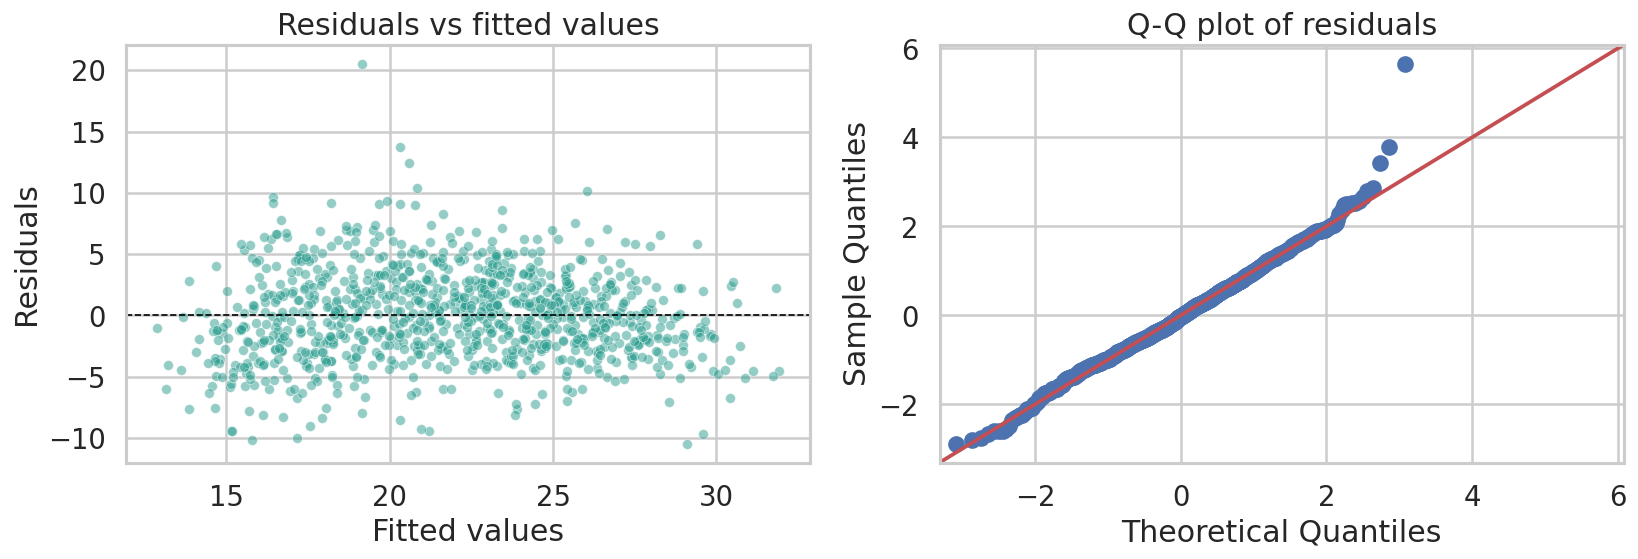

In [14]:
#perform residual analysis on model 3
preferred_model = model_3
diagnostic_df = complete_case.copy()
diagnostic_df["fitted"] = preferred_model.fittedvalues
diagnostic_df["residuals"] = preferred_model.resid
diagnostic_df["std_residuals"] = preferred_model.get_influence().resid_studentized_internal

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#check constant variance on left plot
sns.scatterplot(data=diagnostic_df, x="fitted", y="residuals", alpha=0.5, s=35, color="#2a9d8f", ax=axes[0])
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Residuals vs fitted values")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")

#check for normality of residuals on right plot
sm.qqplot(diagnostic_df["residuals"], line="45", fit=True, ax=axes[1])
axes[1].set_title("Q-Q plot of residuals")

fig.tight_layout()
fig.savefig(FIG_DIR / "model3_residual_diagnostics.png", bbox_inches="tight")
plt.show()

Residuals are broadly centred around zero by the plotting, with no strong non-linear pattern which supports the use of a linear specification.

Although there are some deviations in the upper tail of  the Q–Q plot, but residuals follow the normal reference line well in the centre of the distribution, so only a small number of outlying.

#### 5.1 Spatial Pattern of Model 3 Residuals

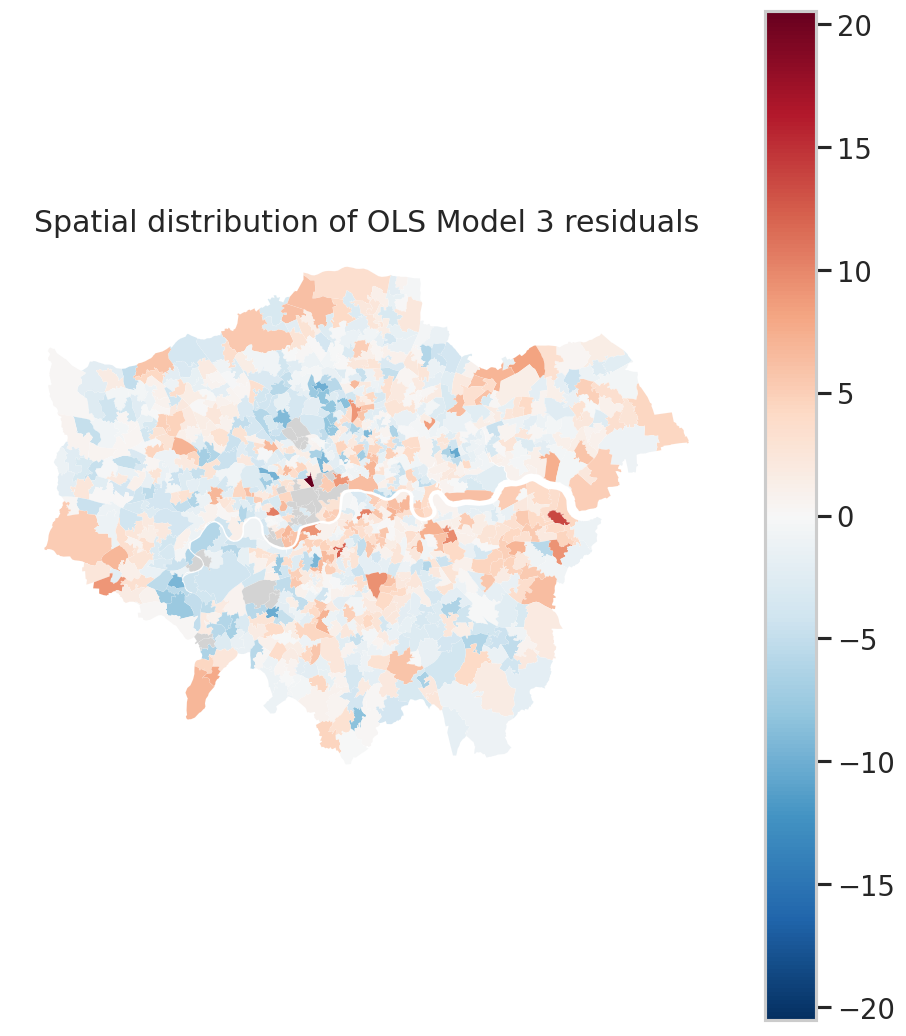

In [15]:
#map the residuals from model 3 to check whether unexplained variation still appears spatially clustered
residual_map = boundary.merge(
    diagnostic_df[["MSOA_code", "residuals"]],
    on="MSOA_code",
    how="left",
)

max_abs_residual = np.nanmax(np.abs(residual_map["residuals"]))

fig, ax = plt.subplots(figsize=(8, 9))
residual_map.plot(
    column="residuals",
    cmap="RdBu_r",
    vmin=-max_abs_residual,
    vmax=max_abs_residual,
    linewidth=0.05,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "Missing"},
    ax=ax,
)
ax.set_title("Spatial distribution of OLS Model 3 residuals")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(FIG_DIR / "model3_residual_choropleth.png", bbox_inches="tight")
plt.show()

Although much of the remaining error is relatively small and spatially dispersed, some localised clusters of positive and negative residuals are still visible.

In [16]:
#if the required spatial statistics packages are available, estimate Moran's I for the model 3 residuals
try:
    import warnings
    from libpysal.weights import KNN, Queen
    from esda.moran import Moran

    residual_geo = residual_map.dropna(subset=["residuals"]).copy().reset_index(drop=True)

    #use a projected CRS for distance-based fallback weights if needed
    if residual_geo.crs is not None and residual_geo.crs.to_epsg() != 27700:
        residual_geo = residual_geo.to_crs(27700)

    #first try polygon contiguity, which is the most natural choice for areal units
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        queen_weights = Queen.from_dataframe(residual_geo, use_index=False)

    if len(getattr(queen_weights, "islands", [])) == len(residual_geo):
        #if contiguity fails because all areas are treated as islands, fall back to centroid-based KNN weights
        residual_centroids = residual_geo.copy()
        residual_centroids["geometry"] = residual_centroids.geometry.centroid
        weights = KNN.from_dataframe(residual_centroids, k=8)
        weight_type = "KNN (k=8)"
        island_count = len(getattr(weights, "islands", []))
        print("Queen contiguity produced only islands, so Moran's I uses KNN fallback weights instead.")
    else:
        weights = queen_weights
        weight_type = "Queen contiguity"
        island_count = len(getattr(weights, "islands", []))

    weights.transform = "r"
    moran_model3 = Moran(residual_geo["residuals"].values, weights, permutations=999)

    moran_table = pd.DataFrame([
        {
            "statistic": "Moran's I",
            "weight_type": weight_type,
            "n_observations": len(residual_geo),
            "n_islands": island_count,
            "value": moran_model3.I,
            "expected_value": moran_model3.EI,
            "p_value_permutation": moran_model3.p_sim,
            "z_score_permutation": moran_model3.z_sim,
        }
    ]).round(4)

    display(moran_table)
    moran_table.to_csv(TABLE_DIR / "model3_residual_morans_i.csv", index=False)

except ModuleNotFoundError:
    print("Moran's I was skipped because libpysal/esda is not installed in the current environment.")
except Exception as exc:
    print("Moran's I could not be computed in the current environment.")
    print(exc)

Queen contiguity produced only islands, so Moran's I uses KNN fallback weights instead.


,statistic,weight_type,n_observations,n_islands,value,expected_value,p_value_permutation,z_score_permutation
0,Moran's I,"KNN (k=8, centroid-based fallback)",959,0,0.1761,-0.001,0.001,11.3776


Moran's I also proof that there's positive spatial autocorrelation in the residuals.

Because Queen contiguity produced only islands for this geometry, the test was calculated using a centroid-based K-nearest neighbours weights matrix (k=8) as a fallback specification.

In particular, the model under-predicts or over-predicts obesity prevalence in some areas, means that some neighbourhood-level influences may remain unobserved.

#### 6. Sensitivity Analysis: Replace IMD with IDACI

In [17]:
#a sensitivity analysis that testing if findings are robust using a child-specific deprivation index (IDACI)
sensitivity_vars = [outcome, "idaci_score_weighted"] + sociodemographic_vars + [green_var]
sensitivity_data = model_data.dropna(subset=sensitivity_vars).copy().reset_index(drop=True)

#sensitivity formula
formula_sensitivity = f"{outcome} ~ idaci_score_weighted + {' + '.join(sociodemographic_vars)} + {green_var}"

#fit the model and compare results with the IMD model
model_sensitivity = smf.ols(formula=formula_sensitivity, data=sensitivity_data).fit(cov_type="HC3")
print(model_sensitivity.summary())

#tidy up for easier comparison
sensitivity_tidy = tidy_model(model_sensitivity, "Sensitivity model")
display(sensitivity_tidy.round(4))
sensitivity_tidy.to_csv(TABLE_DIR / "sensitivity_tidy_results.csv", index=False)

                            OLS Regression Results                            
Dep. Variable:        year6_obese_pct   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     158.1
Date:                Mon, 06 Apr 2026   Prob (F-statistic):          8.19e-169
Time:                        22:01:32   Log-Likelihood:                -2565.5
No. Observations:                 959   AIC:                             5149.
Df Residuals:                     950   BIC:                             5193.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

,term,coef,std_err,p_value,ci_low,ci_high,model
0,Intercept,9.2613,1.0925,0.0000,7.1200,11.4027,Sensitivity model
1,idaci_score_weighted,30.9514,3.6478,0.0000,23.8020,38.1009,Sensitivity model
2,population_density_per_sqkm,0.0001,0.0000,0.0390,0.0000,0.0002,Sensitivity model
3,pct_non_white,0.0399,0.0097,0.0000,0.0208,0.0589,Sensitivity model
4,pct_social_rented,-0.0331,0.0175,0.0580,-0.0673,0.0011,Sensitivity model
5,pct_no_qualifications,0.1735,0.0309,0.0000,0.1130,0.2340,Sensitivity model
6,pct_unemployed_16plus,0.4853,0.2124,0.0223,0.0690,0.9016,Sensitivity model
7,pct_lone_parent_households,0.0518,0.0509,0.3086,-0.0479,0.1515,Sensitivity model
8,green_cover_pct,-0.0182,0.0123,0.1373,-0.0423,0.0058,Sensitivity model


The child focused IDACI measure is used in sensitivity analysis to replaces the overall IMD score in order to test whether the main findings depend on how deprivation is defined.

The results are mainly consistent with the main model, child related deprivation remains strongly positive with Year 6 obesity prevalence, while green cover remains negative but not significant.

Most of socio-demographic covariates remain the same general direction and significance pattern, but the coefficient for lone parent households becomes weaker.


#### 7. Comparison Model: Random Forest

To assess whether the relative importance of predictors is generally consistent under a nonlinear setting, we estimated a random forest regression model as an assist comparison model.

,model,test_rmse,test_r_squared
0,Random Forest,3.6864,0.4966


,variable,importance_mean,importance_std
0,imd_score_weighted,0.2760,0.0450
1,pct_no_qualifications,0.0746,0.0281
2,pct_unemployed_16plus,0.0368,0.0123
3,population_density_per_sqkm,0.0103,0.0088
4,pct_lone_parent_households,0.0073,0.0138
5,pct_non_white,0.0033,0.0171
6,pct_social_rented,0.0021,0.0053
7,green_cover_pct,-0.0002,0.0105


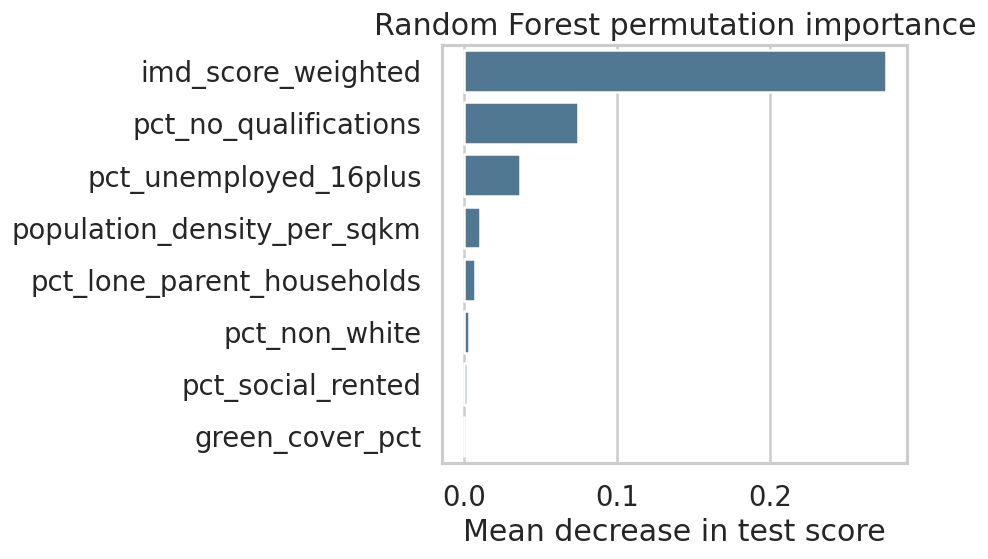

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

rf_vars = model_1_vars + model_2_additions + model_3_additions
rf_data = complete_case[[outcome] + rf_vars].dropna().copy()

X = rf_data[rf_vars]
y = rf_data[outcome]

#split training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

#evaluate model accuracy
y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))#calculate root mean squar error

rf_metrics = pd.DataFrame([
    {
        "model": "Random Forest",
        "test_rmse": rmse,
        "test_r_squared": r2_score(y_test, y_pred),
    }
]).round(4)
display(rf_metrics)
rf_metrics.to_csv(TABLE_DIR / "random_forest_metrics.csv", index=False)

#calculate permutation importance
perm = permutation_importance(rf, X_test, y_test, n_repeats=25, random_state=42, n_jobs=-1)
importance_df = pd.DataFrame({
    "variable": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

display(importance_df.round(4))
importance_df.to_csv(TABLE_DIR / "random_forest_permutation_importance.csv", index=False)

#show variable importance rank
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importance_df, y="variable", x="importance_mean", color="#457b9d", ax=ax)
ax.set_title("Random Forest permutation importance")
ax.set_xlabel("Mean decrease in test score")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIG_DIR / "random_forest_permutation_importance.png", bbox_inches="tight")
plt.show()

In order to assess whether a non-linear specification would affect the ranking of predictors, a random forest model was estimated as a secondary comparison . Its test performance (R^2≈0.497) is lower than the linear model, so greater model flexibility does not produce a clear improvement in this case.

Permutation importance results show that the IMD score the most influential predictor so far, then is the ratio of residents with no qualifications and the ratio of unemployed adults.

In comparison, green cover contributes almost no predictive value once the other variables are included. This comparison reinforces the main regression findings that area deprivation is the dominant correlate of Year 6 obesity prevalence.

## Conclusion

[[ go back to the top ]](#Table-of-contents)

## References

[[ go back to the top ]](#Table-of-contents)